# Tarea Semanal 7
## Autor: Pedro Guzman


## Consigna 
Usando el archivo **ecg.mat** que contiene un registro electrocardiográfico (ECG) registrado durante una prueba de esfuerzo, junto con una serie de variables descriptadas a continuación. Diseñe y aplique los filtros digitales necesarios para mitigar las siguientes fuentes de contaminación:

- Ruido causado por el movimiento de los electrodos (Alta frecuencia).
- Ruido muscular (Alta frecuencia).
- Movimiento de la línea de base del ECG, inducido en parte por la respiración (Baja frecuencia).

**Ayuda:** Los detalles de cómo acceder a ecg.mat los pueden encontrar en `lectura_sigs.py`

Archivo *ECG.mat* (variables)

- **ecg_lead**: Registro de ECG muestreado a *fs* = 1 KHz durante una prueba de esfuerzo
- **qrs_pattern1**: Complejo de ondas QRS normal
- **heartbeat_pattern1**: Latido normal
- **heartbeat_pattern2**: Latido de origen ventricular
- **qrs_detections**: vector con las localizaciones (en # de muestras) donde ocurren los latidos

## Se pide:

**a)** Establezca una plantilla de diseño para los filtros digitales que necesitará para que la señal de ECG se asemeje a los latidos promedio en cuanto a suavidad de los trazos y nivel isoeléctrico nulo.

**Ayuda:** Utilice los resultados del ancho de banda estimado del ECG **en la Tarea Semanal** anterior. Tome como referencia las siguientes morfologías promedio para evaluar cualitativamente la efectividad de los filtros diseñados.

**b)** ¿Cómo obtuvo dichos valores? Describa el procedimiento para establecer los valores de la plantilla.

**c)** Diseñe **al menos** dos filtros FIR y dos IIR para su comparación. Verifique que la respuesta en frecuencia responda a la plantilla de diseño.

**Ayuda:** Para los filtros IIR adopte las aproximaciones de módulo de máxima planicidad, Chebyshev y Cauer. Para los FIR, utilice las metodologías de ventanas, cuadrados mínimos y Parks-McClellan-Remez. Todos implementados en SciPy.Signal

**d)** Evalúe el rendimiento de los filtros que haya diseñado:

1. Verifique que filtra las señales interferentes.
2. Verifique que es inocuo en las zonas donde no hay interferentes.

**Ayuda:** Utilice el siguiente código como referencia para analizar los puntos 1 y 2). **También puede incluir otras regiones que considere de interés.**

---

**Bonus:**

- 💎 Proponga algún tipo de señal, ya sea de la TS anterior u otra que no haya sido analizada y repita el análisis. No olvide explicar su origen y cómo fue digitalizada.


## Solucion Propuesta

Genero los imports de las funciones utilizados en esta tarea semanal

In [1]:
import pandas as pd
from scipy.io import loadmat, whosmat
import numpy as np
from scipy.signal import windows as win
import matplotlib.pyplot as plt
import scipy.signal as sp
from pytc2.sistemas_lineales import plot_plantilla ,group_delay, GroupDelay


Defino las funciones de python utilizadas

In [2]:


def plot_spec(signal, fs, tipo="full", win="rect"):
    N = len(signal)

    # Selección de ventana
    ventanas = {
        "rect":     np.ones(N),
        "hann":     np.hanning(N),
        "hamming":  np.hamming(N),
        "blackman": np.blackman(N),
        "kaiser":   np.kaiser(N, beta=6)
    }
    w = ventanas.get(win, np.ones(N))

    # Corrección de amplitud por la ventana
    espec = np.abs(np.fft.fft(signal * w)) / np.sum(w)
    f = np.fft.fftfreq(N, d=1/fs)

    if tipo == "full":
        espec = np.fft.fftshift(espec)
        f     = np.fft.fftshift(f)
    elif tipo == "half":
        mitad = f >= 0
        f     = f[mitad]
        espec = espec[mitad]

    plt.figure()
    plt.title(f'Espectro de la señal ({win})')
    plt.plot(f, espec)
    plt.grid()
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Amplitud [V]")
    plt.show()

def estimate_freq_from_time_signal(t, x):
    """
    Estima la frecuencia de una señal senoide usando cruces por cero.
    t: vector de tiempos [s]
    x: vector de señal
    Devuelve frecuencia en Hz
    """
    # Eliminar componente DC
    x = x - np.mean(x)
    
    # Detectar cruces por cero (de signo)
    signs = np.sign(x)
    zero_crossings = np.where(np.diff(signs) != 0)[0]
    
    if len(zero_crossings) < 2:
        raise ValueError("No se detectaron suficientes cruces por cero.")
    
    # Calcular los tiempos de cruce por cero
    t_cross = t[zero_crossings]
    
    # Diferencias entre tiempos consecutivos (mitad de período)
    dt = np.diff(t_cross)
    
    # Frecuencia promedio (recordá que dos cruces = medio período)
    f_est = 1.0 / (2 * dt)
    return np.mean(f_est) , np.std(f_est,ddof=1) , len(f_est)

def FM_demod (señal,fs):
    return np.angle(señal[:-1]*np.conjugate(señal[1:]))*fs/(2*np.pi)


Abro el archivo de la senal de ECG registrada.

In [3]:
# --- MAT ---
fs = 1000
mat_struct = loadmat('./ECG_TP4.mat')
ecg_one_lead = mat_struct['ecg_lead'].flatten()
N = len(ecg_one_lead)
t_ecg = np.arange(N) / fs
# Flatten the heartbeat patterns (same as you did for ecg_one_lead)
hb_1 = mat_struct['heartbeat_pattern1'].flatten()
hb_2 = mat_struct['heartbeat_pattern2'].flatten()

# Create their own time axes based on their actual length
t_hb1 = np.arange(len(hb_1)) / fs
t_hb2 = np.arange(len(hb_2)) / fs

**a)** **b)** Para la plantilla de diseño tome la decision de que el ripple en banda de paso sea de 1dB y la atenuacion en banda de rechazo de 40dB, como voy a utilizar la funcion filtfilt para el filtrado de la señal (Esto proque filtro en computadora, si filtro con Hardware o una FPGA no puedo aplicar la funcion de filtrado en tiempo real con filtfilt), necesito dividir los parametros a la mitad, estos es debido a que la funcion filtfilt aplica la funcion de filtrado dos veces pero la segunda lo aplica de forma conjugada, de manera de tener un filtro de fase 0 (Fase lineal 0 y retardo de grupo constante). Muy util para el analisis en computadora.

Para los vlores de ancho de banda me base en la tarea semanal anterior, la frecuencia de pass depende principalmente del ancho de banda y ademas de que queremos eliminar la señal de continua. Las frecuencias de stop la elegi para no tener que pasar por la frecuencia de linea de 50Hz

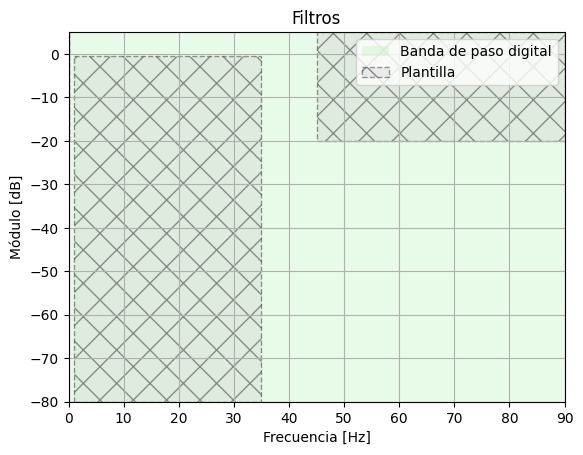

In [4]:
ripple = 0.5 # dB
atenuacion = 20 # dB

ws1 = .001 #Hz
wp1 = 1 #Hz
wp2 = 35.0 #Hz
ws2 = 45 #Hz

plt.figure()

plt.title('Filtros')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.grid()
plt.axis([0, 90, -80, 5 ]);

axes_hdl = plt.gca()

plot_plantilla(filter_type = 'bandpass', fpass = (wp1, wp2), fstop =  (ws1, ws2), ripple = ripple, attenuation = atenuacion, fs = fs)
_ = axes_hdl.legend()

plt.show()

**c)** Procedo con el diseño de los filtros IIR, empiezo con un filtro Butter y despues con otro filtro Chebyshev.

In [5]:
sos_iir_cheby2 = sp.iirdesign(wp=[wp1-0.1,wp2+1], ws=[ws1,ws2], gpass=ripple, gstop=atenuacion, output='sos', analog=False, ftype='cheby2', fs = fs)
sos_iir_butter = sp.iirdesign(wp=[wp1-0.1,wp2+1], ws=[ws1,ws2], gpass=ripple, gstop=atenuacion, output='sos', analog=False, ftype='butter', fs = fs)

w_rad = np.concatenate( [ np.logspace(start = -2, stop = np.log10(2), num = 1000 ),
                       np.linspace(start = 2.1, stop = 34, num = 1000 ),
                       np.logspace(start = np.log10(34.1), stop = np.log10(52), num = 1000 ),
                       np.linspace(start = 52.1, stop = fs/2, num = 1000 )] )

w_rad1, h_iir_cheby2 = sp.freqz_sos(sos_iir_cheby2, worN=w_rad, fs = fs)
w_rad2, h_iir_butter = sp.freqz_sos(sos_iir_butter, worN=w_rad, fs = fs)

print(f"Orden del Filtro IIR Cheby 2: {sos_iir_cheby2.shape[0]*2}")
print(f"Orden del Filtro IIR Butter : {sos_iir_butter.shape[0]*2}")


Orden del Filtro IIR Cheby 2: 12
Orden del Filtro IIR Butter : 30


**c)** Procedo con el diseño de los filtros FIR

In [6]:
fig_sz_x, fig_sz_y = 12, 5

# -----------------------------------------------
# FILTRO 1: FIR - Ventanas Hamming
# -----------------------------------------------
ws1_ham = 0.5   # Hz - Frecuencia de stop inferior
wp1_ham = 0.8    # Hz - Frecuencia de paso inferior
wp2_ham = 36   # Hz - Frecuencia de paso superior
ws2_ham = 38.0   # Hz - Frecuencia de stop superior

cant_coeficientes_box = 1801  # Impar para FIR tipo I

num_box = sp.firwin2(
    cant_coeficientes_box,
    freq   = (0, ws1_ham, wp1_ham, wp2_ham, ws2_ham, fs/2),
    gain   = (0,       0,       1,       1,       0,    0),
    window = 'boxcar',antisymmetric=True,
    fs     = fs
)

##Se pone antisymmetric en true para tener un cero en DC de manera de poder eliminar la continua mas facilmente.

orden_box = num_box.shape[0] - 1
print(f"[FIR Boxcar]          Orden: {orden_box}  |  Coeficientes: {num_box.shape[0]}")

# -----------------------------------------------
# FILTRO 2: FIR - Cuadrados Minimos
# -----------------------------------------------

# Predistorsiono la plantilla
ws1_ls = 0.1    # Hz - Frecuencia de stop inferior
wp1_ls = 1    # Hz - Frecuencia de paso inferior
wp2_ls = 35   # Hz - Frecuencia de paso superior
ws2_ls = 36   # Hz - Frecuencia de stop superior

cant_coeficientes_ls = 1901  # Impar para FIR tipo I

bands   = [0, ws1_ls, wp1_ls, wp2_ls, ws2_ls, fs/2]
gain    = [0,      0,      1,      1,      0,    0]

num_ls = sp.firls(cant_coeficientes_ls, bands, gain, fs=fs)

orden_ls = num_ls.shape[0] - 1
print(f"[FIR Cuad. Mínimos]    Orden: {orden_ls}  |  Coeficientes: {num_ls.shape[0]}")


# -----------------------------------------------
# FILTRO 3: FIR - Remez
# -----------------------------------------------

# Predistorsiono la plantilla
ws1_rm = 0.1    # Hz - Frecuencia de stop inferior
wp1_rm = 1    # Hz - Frecuencia de paso inferior
wp2_rm = 35   # Hz - Frecuencia de paso superior
ws2_rm = 36   # Hz - Frecuencia de stop superior

cant_coeficientes_rm = 1151  

bands   = [0, ws1_rm, wp1_rm, wp2_rm, ws2_rm, fs/2]
gain    = [0   ,   1,    0]

num_rm = sp.remez(cant_coeficientes_rm, bands, gain, fs=fs)

orden_rm = num_rm.shape[0] - 1
print(f"[FIR Remez]    Orden: {orden_rm}  |  Coeficientes: {num_rm.shape[0]}")




w = np.concatenate( [ np.logspace(start = -2, stop = np.log10(2), num = 1000 ),
                       np.linspace(start = 2.1, stop = 34, num = 1000 ),
                       np.logspace(start = np.log10(34.1), stop = np.log10(52), num = 1000 ),
                       np.linspace(start = 52.1, stop = fs/2, num = 1000 )] )


w1, hh_box = sp.freqz(num_box, 1.0, w, fs=fs)
w2, hh_ls  = sp.freqz(num_ls,  1.0, w, fs=fs)
w3, hh_rm  = sp.freqz(num_rm,  1.0, w, fs=fs)

[FIR Boxcar]          Orden: 1800  |  Coeficientes: 1801
[FIR Cuad. Mínimos]    Orden: 1900  |  Coeficientes: 1901
[FIR Remez]    Orden: 1150  |  Coeficientes: 1151


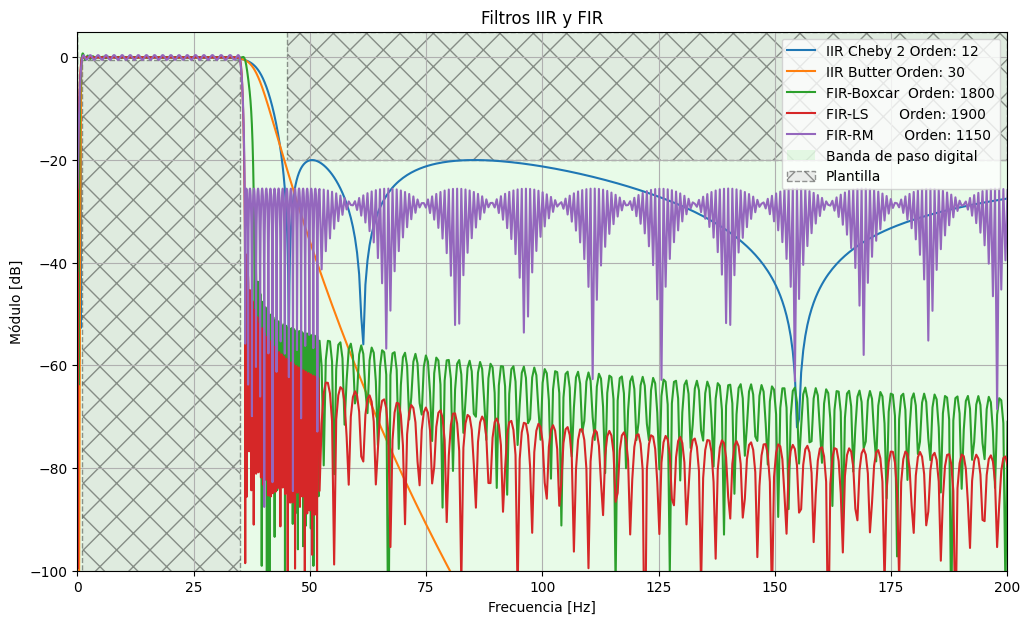

In [7]:
plt.figure(figsize=(12,7))

plt.plot(w_rad1, 20*np.log10(np.abs(h_iir_cheby2)+1e-12), label = 'IIR Cheby 2 Orden: {:d}'.format(sos_iir_cheby2.shape[0]*2) )
plt.plot(w_rad2, 20*np.log10(np.abs(h_iir_butter)+1e-12), label = 'IIR Butter Orden: {:d}'.format(sos_iir_butter.shape[0]*2) )
plt.plot(w1, 20 * np.log10(abs(hh_box) + 1e-12), label='FIR-Boxcar  Orden: {:d}'.format(orden_box))
plt.plot(w2, 20 * np.log10(abs(hh_ls) + 1e-12), label='FIR-LS       Orden: {:d}'.format(orden_ls))
plt.plot(w3, 20 * np.log10(abs(hh_rm) + 1e-12), label='FIR-RM       Orden: {:d}'.format(orden_rm))

plt.title('Filtros IIR y FIR')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.grid()
plt.axis([0, 200, -120, 5 ]);

axes_hdl = plt.gca()

plot_plantilla(filter_type = 'bandpass', fpass = (wp1, wp2), fstop =  (ws1, ws2), ripple = ripple, attenuation = atenuacion, fs = fs)
_ = axes_hdl.legend()

plt.show()

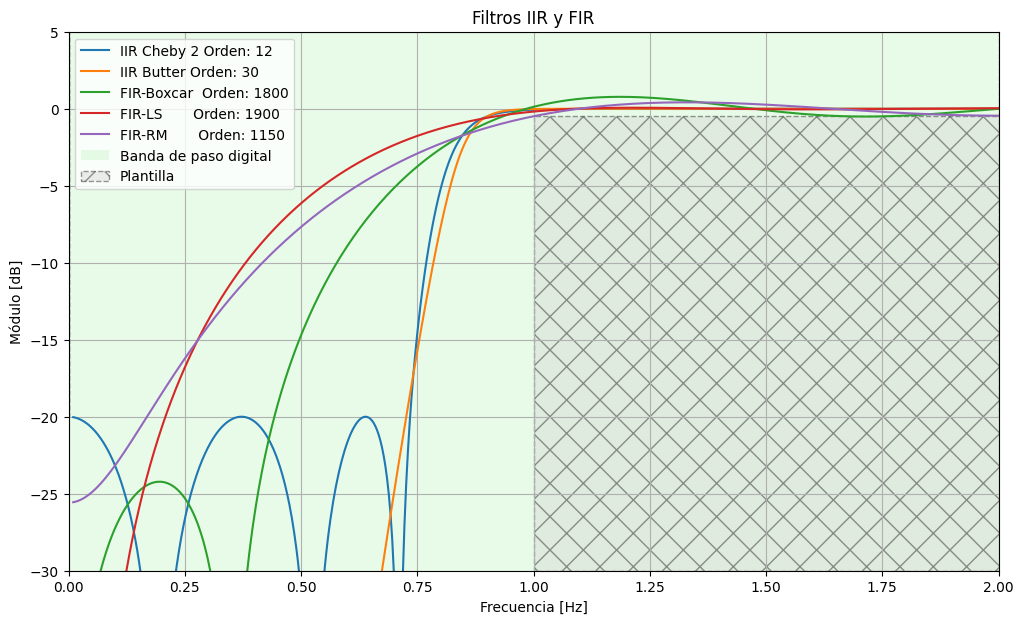

In [8]:
plt.figure(figsize=(12,7))

plt.plot(w_rad, 20*np.log10(np.abs(h_iir_cheby2)+1e-12), label = 'IIR Cheby 2 Orden: {:d}'.format(sos_iir_cheby2.shape[0]*2) )
plt.plot(w_rad, 20*np.log10(np.abs(h_iir_butter)+1e-12), label = 'IIR Butter Orden: {:d}'.format(sos_iir_butter.shape[0]*2) )
plt.plot(w, 20 * np.log10(abs(hh_box) + 1e-12), label='FIR-Boxcar  Orden: {:d}'.format(orden_box))
plt.plot(w, 20 * np.log10(abs(hh_ls) + 1e-12), label='FIR-LS       Orden: {:d}'.format(orden_ls))
plt.plot(w3, 20 * np.log10(abs(hh_rm) + 1e-12), label='FIR-RM       Orden: {:d}'.format(orden_rm))

plt.title('Filtros IIR y FIR')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.grid()
plt.axis([0, 2, -30, 5 ]);

axes_hdl = plt.gca()

plot_plantilla(filter_type = 'bandpass', fpass = (wp1, wp2), fstop =  (ws1, ws2), ripple = ripple, attenuation = atenuacion, fs = fs)
_ = axes_hdl.legend()

plt.show()

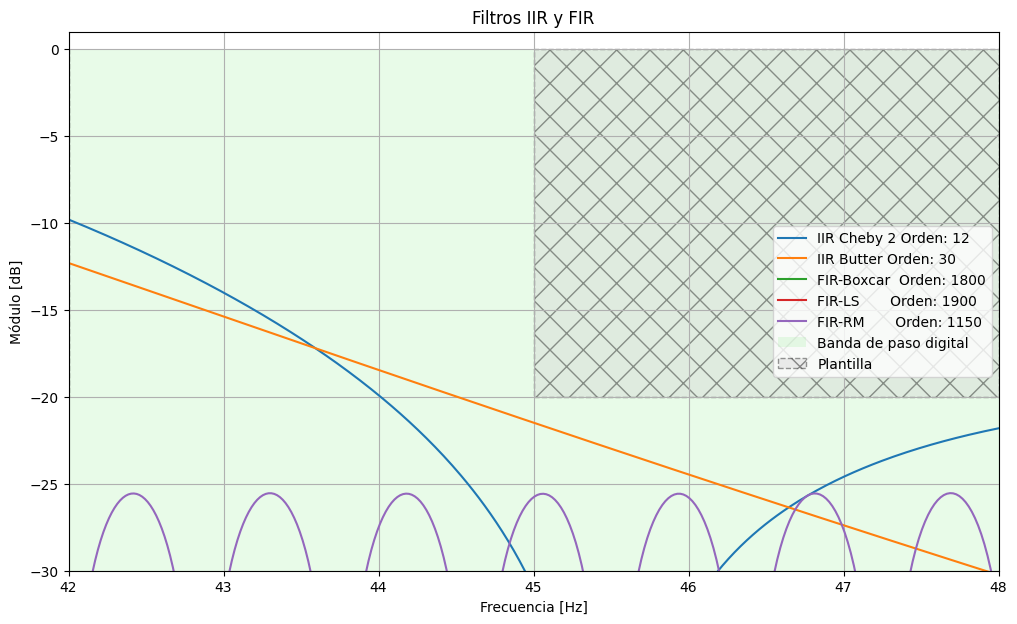

In [9]:
plt.figure(figsize=(12,7))

plt.plot(w_rad, 20*np.log10(np.abs(h_iir_cheby2)+1e-12), label = 'IIR Cheby 2 Orden: {:d}'.format(sos_iir_cheby2.shape[0]*2) )
plt.plot(w_rad, 20*np.log10(np.abs(h_iir_butter)+1e-12), label = 'IIR Butter Orden: {:d}'.format(sos_iir_butter.shape[0]*2) )
plt.plot(w, 20 * np.log10(abs(hh_box) + 1e-12), label='FIR-Boxcar  Orden: {:d}'.format(orden_box))
plt.plot(w, 20 * np.log10(abs(hh_ls) + 1e-12), label='FIR-LS       Orden: {:d}'.format(orden_ls))
plt.plot(w3, 20 * np.log10(abs(hh_rm) + 1e-12), label='FIR-RM       Orden: {:d}'.format(orden_rm))

plt.title('Filtros IIR y FIR')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.grid()
plt.axis([42, 48, -30, 0 ]);

axes_hdl = plt.gca()

plot_plantilla(filter_type = 'bandpass', fpass = (wp1, wp2), fstop =  (ws1, ws2), ripple = ripple, attenuation = atenuacion, fs = fs)
_ = axes_hdl.legend()

plt.show()

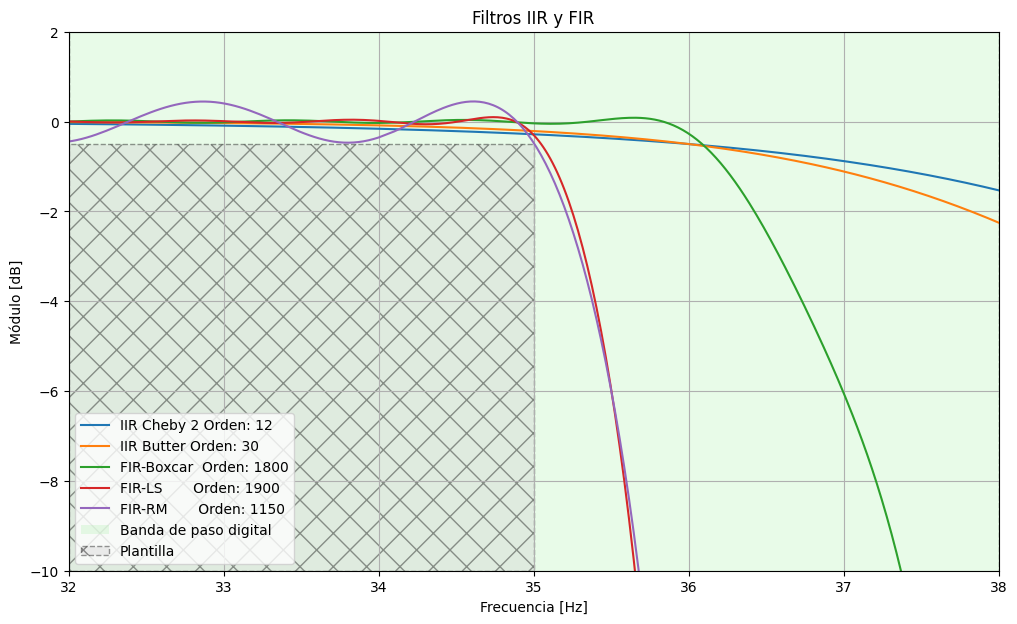

In [10]:
plt.figure(figsize=(12,7))

plt.plot(w_rad, 20*np.log10(np.abs(h_iir_cheby2)+1e-12), label = 'IIR Cheby 2 Orden: {:d}'.format(sos_iir_cheby2.shape[0]*2) )
plt.plot(w_rad, 20*np.log10(np.abs(h_iir_butter)+1e-12), label = 'IIR Butter Orden: {:d}'.format(sos_iir_butter.shape[0]*2) )
plt.plot(w, 20 * np.log10(abs(hh_box) + 1e-12), label='FIR-Boxcar  Orden: {:d}'.format(orden_box))
plt.plot(w, 20 * np.log10(abs(hh_ls) + 1e-12), label='FIR-LS       Orden: {:d}'.format(orden_ls))
plt.plot(w3, 20 * np.log10(abs(hh_rm) + 1e-12), label='FIR-RM       Orden: {:d}'.format(orden_rm))

plt.title('Filtros IIR y FIR')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.grid()
plt.axis([32, 38, -10, 2 ]);

axes_hdl = plt.gca()

plot_plantilla(filter_type = 'bandpass', fpass = (wp1, wp2), fstop =  (ws1, ws2), ripple = ripple, attenuation = atenuacion, fs = fs)
_ = axes_hdl.legend()

plt.show()

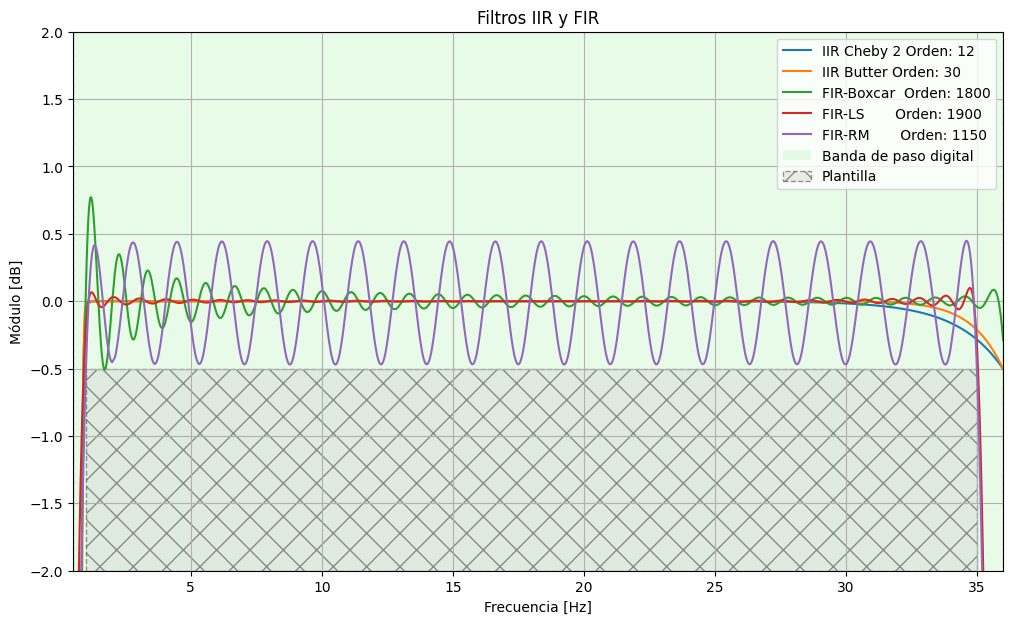

In [11]:
plt.figure(figsize=(12,7))

plt.plot(w_rad, 20*np.log10(np.abs(h_iir_cheby2)+1e-12), label = 'IIR Cheby 2 Orden: {:d}'.format(sos_iir_cheby2.shape[0]*2) )
plt.plot(w_rad, 20*np.log10(np.abs(h_iir_butter)+1e-12), label = 'IIR Butter Orden: {:d}'.format(sos_iir_butter.shape[0]*2) )
plt.plot(w, 20 * np.log10(abs(hh_box) + 1e-12), label='FIR-Boxcar  Orden: {:d}'.format(orden_box))
plt.plot(w, 20 * np.log10(abs(hh_ls) + 1e-12), label='FIR-LS       Orden: {:d}'.format(orden_ls))
plt.plot(w3, 20 * np.log10(abs(hh_rm) + 1e-12), label='FIR-RM       Orden: {:d}'.format(orden_rm))

plt.title('Filtros IIR y FIR')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.grid()
plt.axis([0.5, 36, -2, 2 ]);

axes_hdl = plt.gca()

plot_plantilla(filter_type = 'bandpass', fpass = (wp1, wp2), fstop =  (ws1, ws2), ripple = ripple, attenuation = atenuacion, fs = fs)
_ = axes_hdl.legend()

plt.show()

Se verifica que todos los filtros cumplen la plantilla, algunos de un orden, otros de otro orden. La plantilla fue disenada para usar filtfilt en la funcion de filtrado. Por eso se espera que atenue 20dB en cada banda de stop. Fue todo un diseno iterativo el de los filtros, he predistorsionado las plantillas para que los mismos cumplan las especificaciones propuestas haciendo un trade-off con los taps y las bandas de paso y rechazo.


Se procede a aplicar filtfilt a la senal de ECG con cada filtro. al usar filtfilt perdemos la implementacion en tiempo real, pero si estamos analizando una senal en la computadora o postprocesamiento y no es necesario en tiempo real, nos lo podemos permitir. Lo ideal seria que si queremos eliminar la distorsion de fase, debemos usar un filtro FIR de fase lineal.

In [12]:
ECG_F_cheby2 = sp.sosfiltfilt(sos_iir_cheby2, ecg_one_lead)
ECG_F_butter = sp.sosfiltfilt(sos_iir_butter, ecg_one_lead)
ECG_f_win = sp.filtfilt(num_box, 1, ecg_one_lead)
ECG_f_sqmin = sp.filtfilt(num_ls, 1, ecg_one_lead)
ECG_f_rm = sp.filtfilt(num_rm, 1, ecg_one_lead)


In [13]:
###################################
#%% Regiones de interés #
###################################

regs_interes_con_ruido = (
       # np.array([0.005, 0.015]) *60*fs, # minutos a muestras
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )

regs_interes_sin_ruido = (
        [4000, 5500], # muestras
        [10e3, 10.6e3], # muestras
        [10.25e3, 10.4e3], # muestras
        )



### Comparacion FIR e IIR

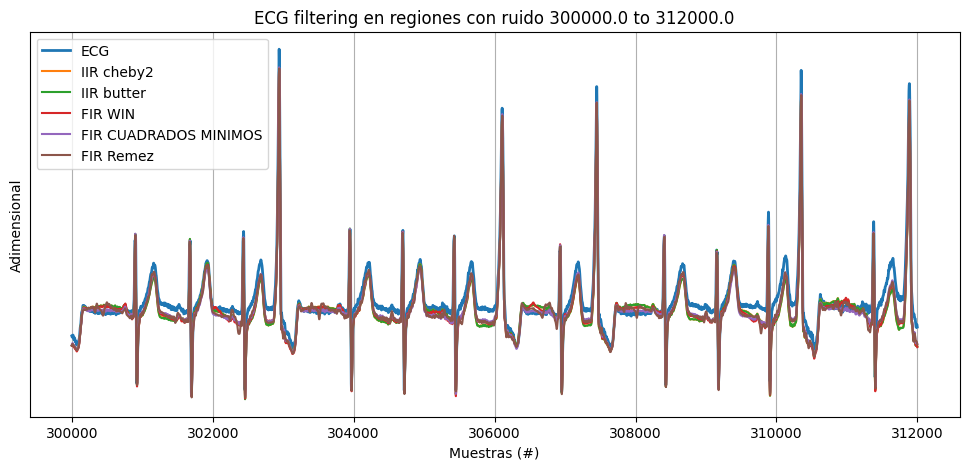

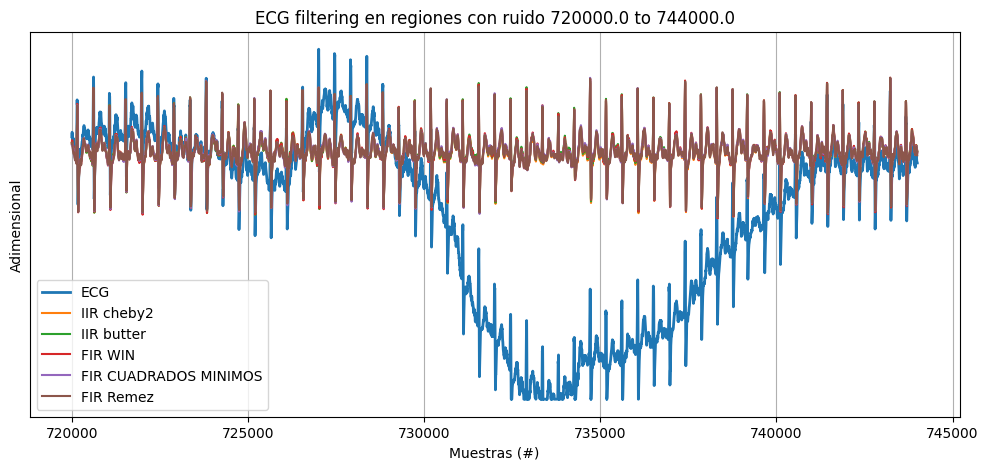

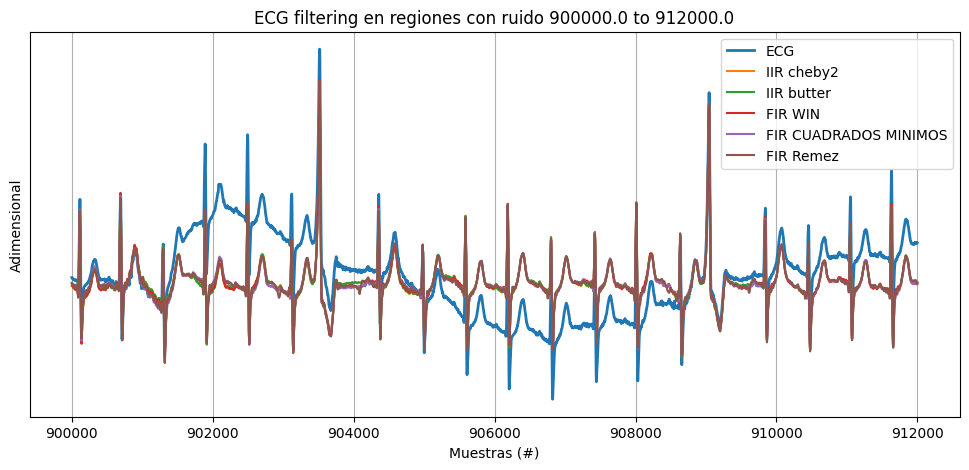

In [14]:
for ii in regs_interes_con_ruido:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([N, ii[1]]), dtype='uint')
   
    plt.figure(figsize=(12,5))
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_F_cheby2[zoom_region], label='IIR cheby2')
    plt.plot(zoom_region, ECG_F_butter[zoom_region], label='IIR butter')
    plt.plot(zoom_region, ECG_f_win[zoom_region], label='FIR WIN')
    plt.plot(zoom_region, ECG_f_sqmin[zoom_region], label='FIR CUADRADOS MINIMOS')
    plt.plot(zoom_region, ECG_f_rm[zoom_region], label='FIR Remez')
    #plt.plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window')
   
    plt.title('ECG filtering en regiones con ruido ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
    plt.grid()
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()

Se puede ver como los filtros eliminan todos la senal continua, y el ruido que aparece en distintas partes de la senal, lo cual nos dice que nuestros filtros son exitosos para eliminar el ruido y la senal continua

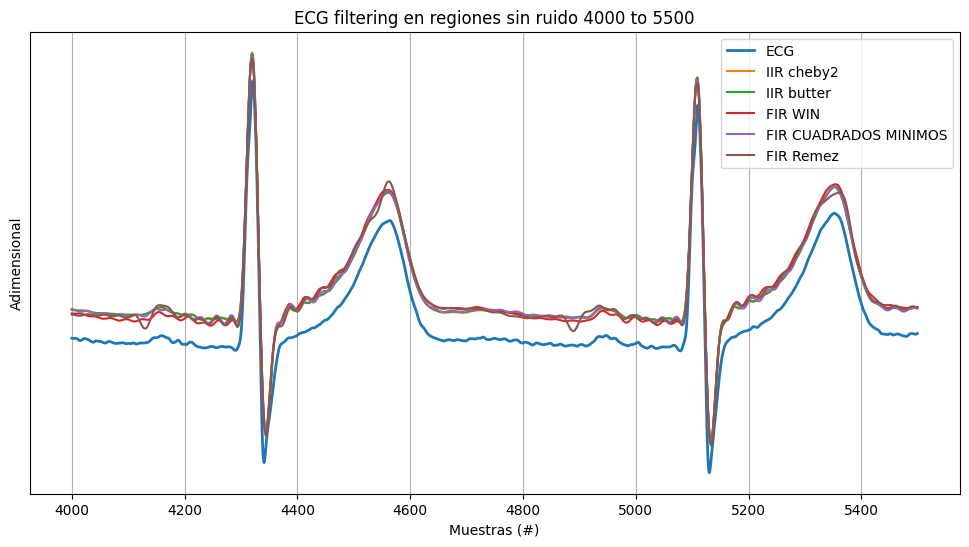

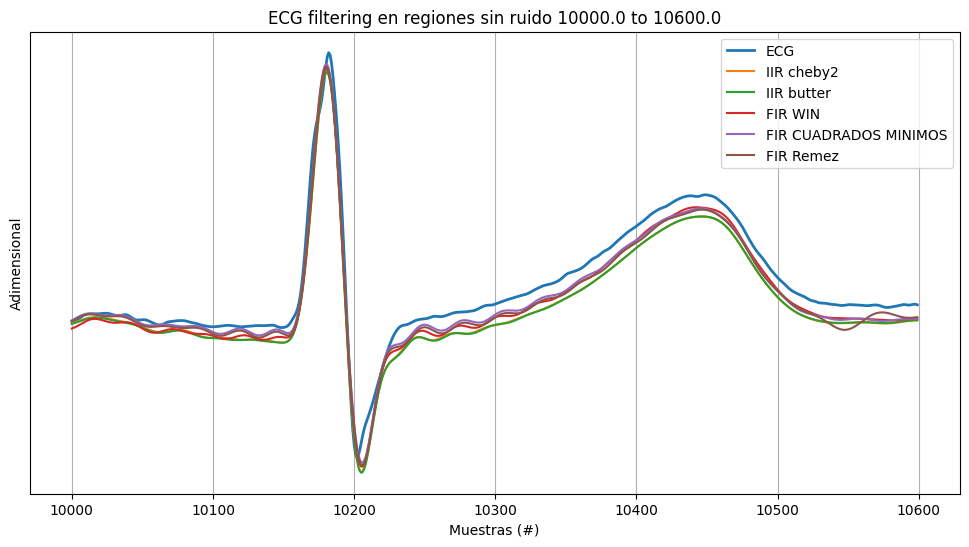

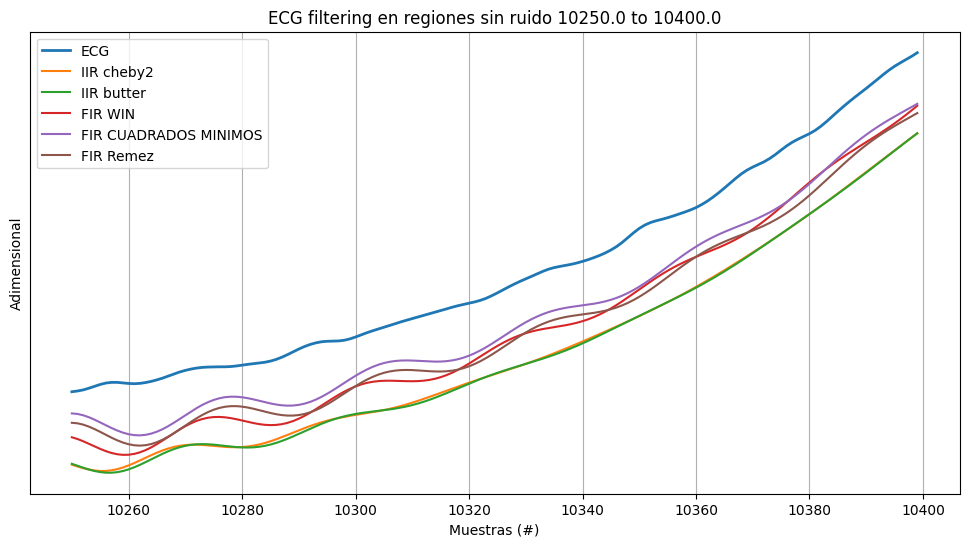

In [15]:
for ii in regs_interes_sin_ruido:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([N, ii[1]]), dtype='uint')
   
    plt.figure(figsize=(12,6))
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_F_cheby2[zoom_region], label='IIR cheby2')
    plt.plot(zoom_region, ECG_F_butter[zoom_region], label='IIR butter')
    plt.plot(zoom_region, ECG_f_win[zoom_region], label='FIR WIN')
    plt.plot(zoom_region, ECG_f_sqmin[zoom_region], label='FIR CUADRADOS MINIMOS')
    plt.plot(zoom_region, ECG_f_rm[zoom_region], label='FIR Remez')
   
    plt.title('ECG filtering en regiones sin ruido ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
    plt.grid()
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()

Tenemos una distorsion de modulo que nos causa que en las regiones de interes de la senal sin ruido, distorsion la senal de ECG, la cual deberia mantenerla exactamente igual, se ve un comportamiento oscilatorio que se puede estudiar en materias como Sistemas de Control, debido a que se analiza la respuesta al impulso, para ver como se comporta su transitorio.

### Bonus Señal de FM demodulada


Generamos una senal FM que tiene como mensaje una senoidal. Adquirimos la senal con el osciloscopio mediante instrumentacion virtual por pyvisa y guardamos los datos en un .csv para su posterior procesamiento mediante FFT y filtrado digital para para poder ver el espectro y a su vez poder recuperar el mensaje.

El diagrama de conexionado es el siguiente

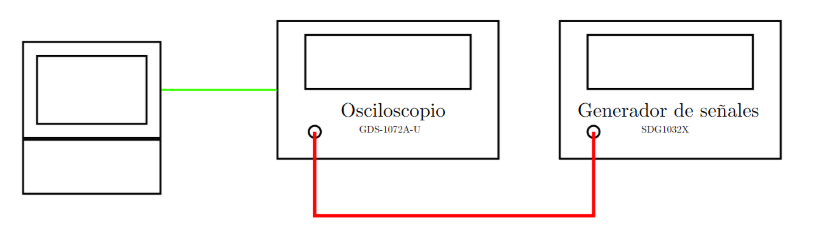


In [16]:
data1 = np.genfromtxt("FM.csv",delimiter=",",usecols=(0,1))
t = data1[0: , 0]
ch1 = data1[0: , 1] #Tension de entrada
fs = 1/(t[2]-t[1])
ch1_shift=ch1*np.exp(1j*2*np.pi*1e6*t) #Muevo la senal a banda base

### Espectro de la senal en banda base

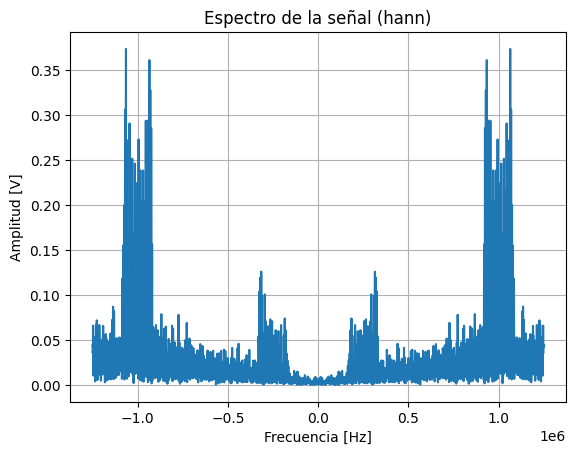

In [17]:
plot_spec(ch1, fs, tipo="full", win="hann")

### Espectro de la senal en banda base

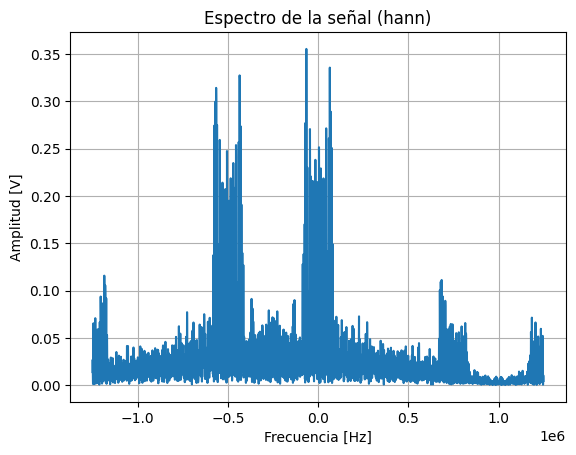

In [18]:
plot_spec(ch1_shift, fs, tipo="full", win="hann")

### Filtrado de la senal con filtros IIR

In [19]:
sos_iir_cheby2 = sp.iirdesign(wp=100e3, ws=150e3, gpass=0.5, gstop=20, output='sos', analog=False, ftype='cheby2', fs = fs)
sos_iir_butter = sp.iirdesign(wp=100e3, ws=150e3, gpass=0.5, gstop=20, output='sos', analog=False, ftype='butter', fs = fs)

fm_filtrada_cheby2 = sp.sosfiltfilt(sos_iir_cheby2, ch1_shift)
fm_filtrada_butter = sp.sosfiltfilt(sos_iir_butter, ch1_shift)

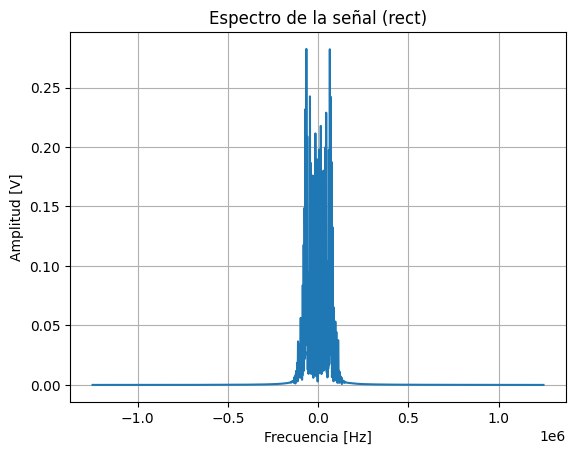

In [20]:
plot_spec(fm_filtrada_butter,fs)

Se puede ver como el Filtro Butter cumple su tarea perfectamente

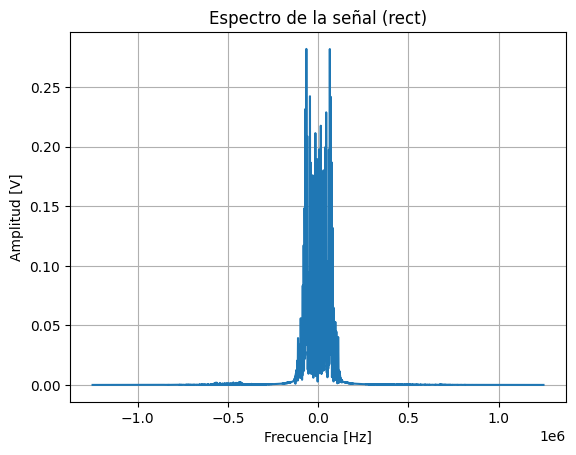

In [21]:
plot_spec(fm_filtrada_cheby2,fs)

Se puede ver como el Filtro Cheby2 cumple su tarea perfectamente

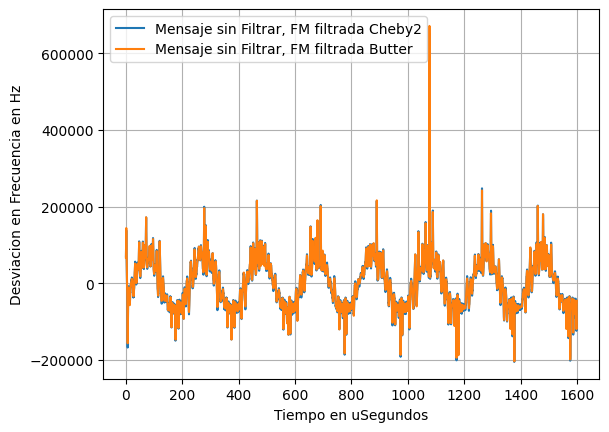

In [22]:

mensaje_butter=FM_demod(fm_filtrada_butter,fs)
mensaje_cheby2=FM_demod(fm_filtrada_cheby2,fs)


plt.figure()
plt.plot(t[:len(mensaje_cheby2)]*1000*1000,mensaje_cheby2, label = "Mensaje sin Filtrar, FM filtrada Cheby2")
plt.plot(t[:len(mensaje_butter)]*1000*1000,mensaje_butter,label  = "Mensaje sin Filtrar, FM filtrada Butter")
plt.grid()
plt.ylabel("Desviacion en Frecuencia en Hz")
plt.xlabel("Tiempo en uSegundos")
plt.legend()
plt.show()

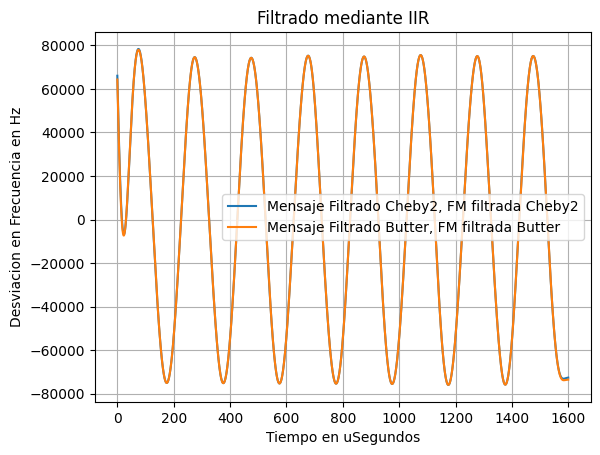

In [23]:
# Frecuencia de corte del filtro paso bajo (Hz)
# Sabemos que esta modulada por un tono entonces podemos poner una frecuencia  bien baja de stop
#del grafico se ve que tiene una frecuencia de aproximadamente 5kHz entonces ponemos una frecuencia de corte de 
# Orden del filtro
#lo ideal seria ver el espectro de la senal para ver las componentes frecuenciales de ruido

sos_iir_cheby2 = sp.iirdesign(wp=10e3, ws=100e3, gpass=0.5, gstop=40, output='sos', analog=False, ftype='cheby2', fs = fs)
sos_iir_butter = sp.iirdesign(wp=10e3, ws=100e3, gpass=0.5, gstop=40, output='sos', analog=False, ftype='butter', fs = fs)

mensaje_filtrado_cheby2 = sp.sosfiltfilt(sos_iir_cheby2, mensaje_cheby2)
mensaje_filtrado_butter = sp.sosfiltfilt(sos_iir_butter, mensaje_butter)


plt.figure()
plt.title("Filtrado mediante IIR")
plt.plot(t[:len(mensaje_cheby2)]*1000*1000,mensaje_filtrado_cheby2, label = "Mensaje Filtrado Cheby2, FM filtrada Cheby2")
plt.plot(t[:len(mensaje_butter)]*1000*1000,mensaje_filtrado_butter,label  = "Mensaje Filtrado Butter, FM filtrada Butter")
plt.grid()
plt.ylabel("Desviacion en Frecuencia en Hz")
plt.xlabel("Tiempo en uSegundos")
plt.legend()
plt.show()

Se puede ver como perfectametne se recupero el tono senoidal de mensaje de la senal de FM utilizando filtros IIR

### Filtrado de la senal con Filtros FIR

In [24]:

f_pass = 100e3   
f_stop = 150e3   

num_ls = sp.firls(
    1001,
    [0, f_pass, 120e3, fs/2],  
    [1, 1,      0,      0],    
    fs=fs
)


num_rm = sp.remez(
    501,
    [0, f_pass, 120e3, fs/2], 
    [1,         0],           
    fs=fs
)

fm_filtrada_ls = sp.filtfilt(num_ls,1, ch1_shift)
fm_filtrada_rm = sp.filtfilt(num_rm,1, ch1_shift)

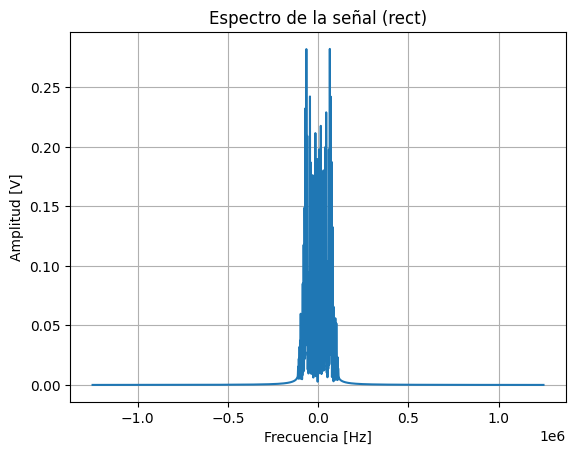

In [25]:
plot_spec(fm_filtrada_ls,fs)

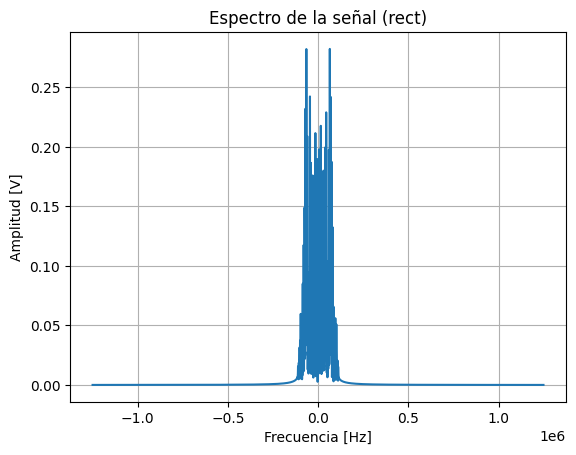

In [26]:
plot_spec(fm_filtrada_rm,fs)

Se puede ver como los dos filtros cumplen perfectamente su tarea al filtrar la senal de FM

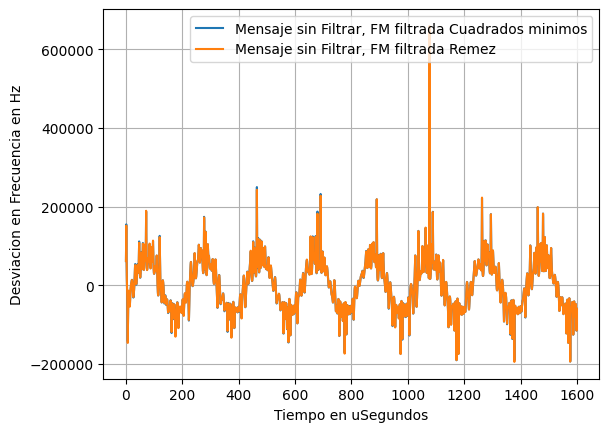

In [27]:

mensaje_ls=FM_demod(fm_filtrada_ls,fs)
mensaje_rm=FM_demod(fm_filtrada_rm,fs)


plt.figure()
plt.plot(t[:len(mensaje_ls)]*1000*1000,mensaje_ls, label = "Mensaje sin Filtrar, FM filtrada Cuadrados minimos")
plt.plot(t[:len(mensaje_rm)]*1000*1000,mensaje_rm,label  = "Mensaje sin Filtrar, FM filtrada Remez")
plt.grid()
plt.ylabel("Desviacion en Frecuencia en Hz")
plt.xlabel("Tiempo en uSegundos")
plt.legend()
plt.show()

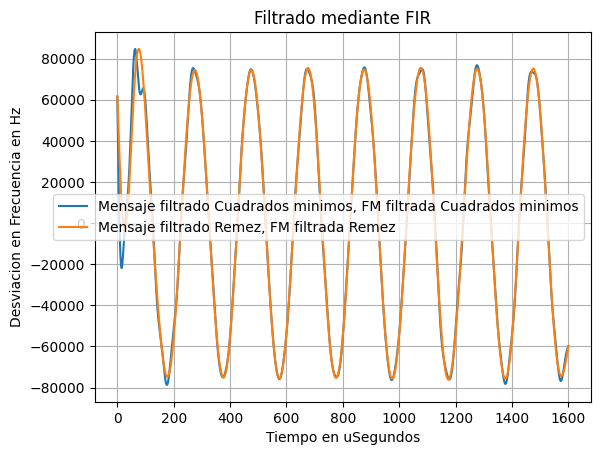

In [28]:

f_pass = 10e3   
f_stop = 100e3   

num_ls = sp.firls(
    1001,
    [0, f_pass, 50e3, fs/2],  
    [1, 1,      0,      0],    
    fs=fs
)


num_rm = sp.remez(
    1001,
    [0, f_pass, 50e3, fs/2], 
    [1,         0],           
    fs=fs
)
mensaje_filtrado_ls = sp.filtfilt(num_ls,1, mensaje_ls)
mensaje_filtrado_rm = sp.filtfilt(num_rm,1, mensaje_rm)



plt.figure()
plt.title("Filtrado mediante FIR")
plt.plot(t[:len(mensaje_filtrado_ls)]*1000*1000,mensaje_filtrado_ls, label = "Mensaje filtrado Cuadrados minimos, FM filtrada Cuadrados minimos")
plt.plot(t[:len(mensaje_filtrado_rm)]*1000*1000,mensaje_filtrado_rm,label  = "Mensaje filtrado Remez, FM filtrada Remez")
plt.grid()
plt.ylabel("Desviacion en Frecuencia en Hz")
plt.xlabel("Tiempo en uSegundos")
plt.legend()
plt.show()

Se puede ver como perfectamente se recupero el tono senoidal de mensaje de la senal de FM utilizando filtros FIR

### Conclusión
Se vio la utilidad de loss filtros digitales para eliminar señales espurias que afectan a nuestra señal de informacion, llamese ruido, cuantizacion o de por si otras señales adyacentes pero en otras frecuencias

Se debe tener en cuenta que el uso del filtrado digital nos afecta la señal con una distorsion de fase y de modulo por mas que apliquemos filtfilt o usemos filtros butter, debido a que no se analiza el comportamiento oscilatorio de la respuesta al impulso, se debe aplicar otro tipo de filtrado a las señales de ECG porque en las partes donde no hay ruido nos deberia dejar la señal tal y como esta pero nuestro filtro la distorsiona levemente con una pequeña oscilacion, como se vio anteriormente .

Aprendi que el diseño de filtros digitales FIR tiene su componente de artesania, ya que se debe predistorsionar la plantilla ya sea cambiando atenuaciones, coeficientes, frecuencias de paso y de stop para que el filtro pueda cumplir la plantilla real, esto es debido a como estan implementadas las funciones en python de FIRWIN, firls y remez. Ademas de que en FIRWIN es necesario elegir la ventana indicada para la tarea a realizar, algunas mas abruptas que otra.

En el bonus pudimos ver como todos los filtros cumplian correctamente su tarea, capaz lo mas recomendable hubiera sido usar un filtro IIR ya que requiere menor costo computacional y que ademas es de menor orden y para eliminar la distorsion de fase del mismo podemos usar filtfilt. Fue un ejemplo muy basico de una señal de FM demodulada. Algo un poco mas interesante hubiera sido grabar la voz y meterle un ruido pseudo aleatorio gaussiano y reproducir la voz con ruido y despues del pasaje de filtros. (Lo hecho anteriormente en LTSPICE y un amplificador diferencial)

Del Bonus me gusto como se acoto perfectamente el ancho de banda de la señal de FM al aplicar los filtros FIR e IIR. Si bien no segui el diseño basico de las plantillas en este bonus, debido a que no se requeria un filtrado muy exacto en ninguna de las dos etapas (FM y mensaje) por tratarse de un tono, en la implementacion del dia a dia de filtrado digital trabajare con la plantillas de filtrado digital.

A la hora de implementar los filtros digitales en tiempo real en hardware, debe tenerse en cuenta que no se puede aplicar filt filt y que no trabajamos con punto flotante, si no en si mismo con punto fijo, lo cual reduce la complejidad del hardware y aumenta la rapidez de los sistemas, el problema que trae esto es que perdemos resolucion en los factores del filtro ya sea FIR o IIR, y como no aplicamos FILT FILT debe tenerse en cuenta la distorsion de fase, la cual la misma debe ser lineal para tener un retardo de grupo constante en nuestra region de trabajo.


### Referencia:

https://github.com/pablodecesare1/Modulacion_de_frecuencia/blob/master/Demodulaci%C3%B3n%20de%20FM.ipynb